In [55]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [56]:
from datetime import date

from aquacrop import AquaCrop, Crop, Soil, Weather

from aquacrop_slovenia import config
from aquacrop_slovenia.plots import plot_yield_timeseries_comparison, plot_yield_scatter, plot_gdd_and_yield, \
    plot_yield_timeseries_residuals
from aquacrop_slovenia.reading_data import get_yield, get_yield_for_comparison, get_co2_for_aquacrop, get_station_weather
from aquacrop_slovenia.parameter_defaults_jablje import jablje_soil_layers, jablje_curve_number, \
    jablje_readily_evaporable_water, jablje_maize_params, jablje_optimal_management, jablje_initial_cond, \
    jablje_groundwater
from aquacrop_slovenia.diagnostics import print_metrics

In [57]:
# Set up working directory for outputs
output_dir = config.RAMDISK_DIR / "testing"
LOCATION = "jablje"

plant and end dates are set to be the same every year - TODO TEMPORARY!!!

We exclude 2017 since we dont have ET data for most of the year

In [58]:
simulation_periods = [
    {
        "start_date": date(year, 1, 1),
        "end_date": date(year, 12, 31),
        "planting_date": date(year, 5, 3),
        "is_seeding_year": True,
    }
for year in range(1993, 2024) if year not in [2017]]

In [59]:
jablje_temperatures, jablje_eto, jablje_rain = get_station_weather(8) # Jablje uses ARSO meteo station 8 data

In [60]:
historical_co2 = get_co2_for_aquacrop("historical")

In [61]:
jablje_weather = Weather(
    location=LOCATION,
    temperatures=jablje_temperatures,
    eto_values=jablje_eto,
    rainfall_values=jablje_rain,
    record_type=1,
    first_day=1,
    first_month=1,
    first_year=1993,
    co2_records=historical_co2
)

In [62]:
jablje_maize = Crop(
    name=f"{LOCATION} maize",
    description=f"{LOCATION} maize uncalibrated",
    params=jablje_maize_params
)

In [63]:
jablje_soil = Soil(
    name=f"{LOCATION} soil",
    description=f"{LOCATION} silt loam soil uncalibrated",
    soil_layers=jablje_soil_layers,
    curve_number=jablje_curve_number,
    readily_evaporable_water=jablje_readily_evaporable_water
)

In [64]:
# Create AquaCrop simulation
simulation = AquaCrop(
    simulation_periods=simulation_periods,
    crop=jablje_maize,
    soil=jablje_soil,
    management=jablje_optimal_management,
    initial_conditions=jablje_initial_cond,
    climate=jablje_weather,
    #ground_water=jablje_groundwater,
    working_dir=output_dir,
    need_daily_output=True,
    need_seasonal_output=True,
    need_harvest_output=False,
    need_evaluation_output=False
)

In [65]:
# Run the simulation
results = simulation.run()
seasonal_results = results["season"]

Setting up working directory at: E:\aquacrop\testing
Running AquaCrop simulation with project file: E:\aquacrop\testing\LIST\PROJECT.PRM
Detected platform: windows (AMD64)
Looking for executable at: C:\Users\rokku\Documents\Code\aquacrop-slovenia\.venv\Lib\site-packages\model\windows\aquacrop.exe
Using AquaCrop executable: E:\aquacrop\testing\aquacrop.exe
AquaCrop simulation completed successfully
Parsing simulation results...
Results successfully parsed


In [66]:
seasonal_results

,RunNr,Day1,Month1,Year1,Rain,ETo,GD,CO2,Irri,Infilt,...,HI,Y(dry),Y(fresh),WPet,Bin,Bout,DayN,MonthN,YearN,Project
0,1,1,1,1993,1180.9,760.6,1135.1,355.97,0.0,895.0,...,40.2,6.534,8.597,1.94,0.0,0.0,31,12,1993,PROJECT.PRM
1,2,1,1,1994,1265.4,745.2,1207.5,357.58,0.0,1023.3,...,46.0,8.123,10.688,2.02,0.0,0.0,31,12,1994,PROJECT.PRM
2,3,1,1,1995,1436.3,695.6,1017.1,359.53,0.0,1077.4,...,46.0,7.194,9.466,1.99,0.0,0.0,31,12,1995,PROJECT.PRM
3,4,1,1,1996,1439.8,644.8,992.3,361.26,0.0,1076.1,...,40.1,6.054,7.966,1.86,0.0,0.0,31,12,1996,PROJECT.PRM
4,5,1,1,1997,1144.1,725.2,1104.4,362.43,0.0,919.0,...,45.6,8.344,10.979,2.17,0.0,0.0,31,12,1997,PROJECT.PRM
5,6,1,1,1998,1347.8,709.7,1200.0,365.14,0.0,1033.3,...,41.4,7.091,9.330,2.15,0.0,0.0,31,12,1998,PROJECT.PRM
6,7,1,1,1999,1390.5,679.8,1238.6,366.96,0.0,1112.6,...,46.2,8.317,10.944,2.17,0.0,0.0,31,12,1999,PROJECT.PRM
7,8,1,1,2000,1439.3,747.8,1231.1,368.25,0.0,1126.6,...,37.7,6.489,8.538,1.67,0.0,0.0,31,12,2000,PROJECT.PRM
8,9,1,1,2001,1169.9,699.8,1163.8,369.65,0.0,935.4,...,44.9,7.708,10.142,2.03,0.0,0.0,31,12,2001,PROJECT.PRM
9,10,1,1,2002,1176.9,689.4,1176.5,371.87,0.0,980.0,...,46.0,8.423,11.083,2.29,0.0,0.0,31,12,2002,PROJECT.PRM


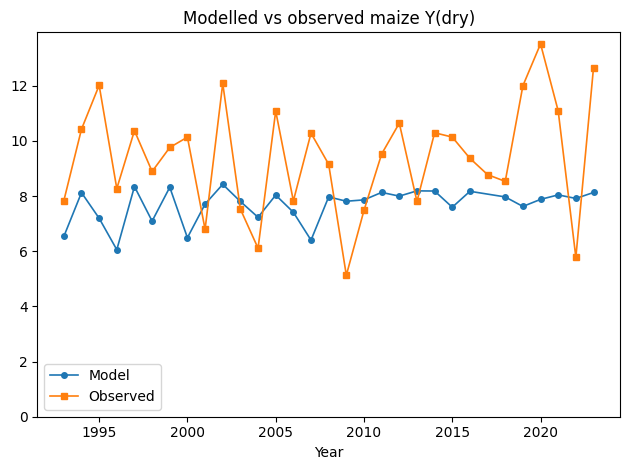

In [67]:
plot_yield_timeseries_comparison(seasonal_results, get_yield(LOCATION, "grain", "A", "N3"), "Y(dry)")

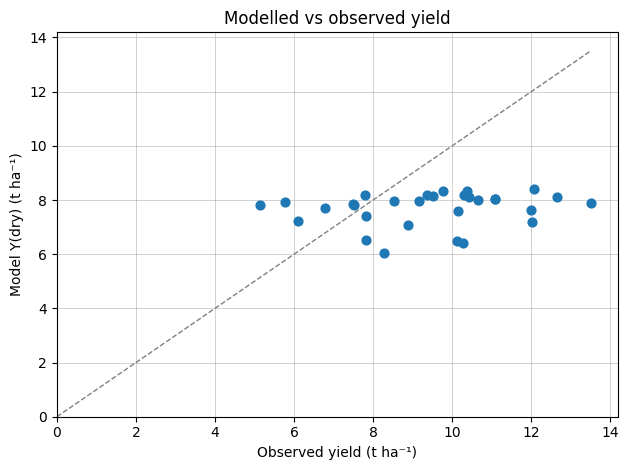

In [68]:
plot_yield_scatter(seasonal_results, get_yield(LOCATION, "grain", "A", "N3"))

In [69]:
print_metrics(seasonal_results, get_yield_for_comparison(LOCATION, "grain", "A", "N3"), "Y(dry)", "Grain")

=== Grain ===
  RMSE:       2.6679
  R2:         -0.6904
  NSE:        -0.6904
  KGE:        -0.0932
  mKGE:       -0.0513
  KGE_r:      0.1813
  KGE_beta:   0.8164
  KGE_alpha:  0.2992
  mKGE_alpha: 0.3665


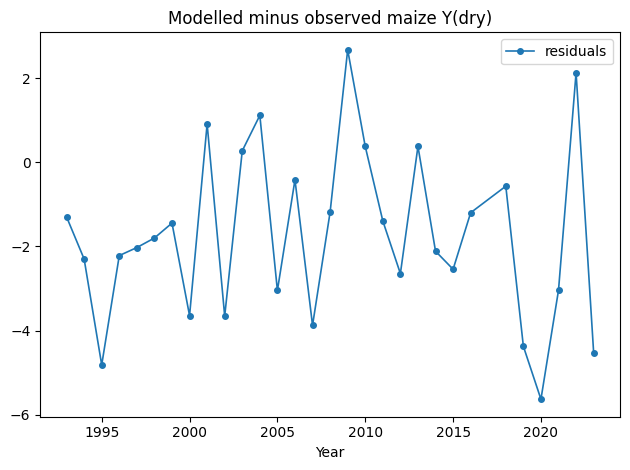

In [70]:
plot_yield_timeseries_residuals(seasonal_results, get_yield_for_comparison(LOCATION, "grain", "A", "N3"), "Y(dry)")

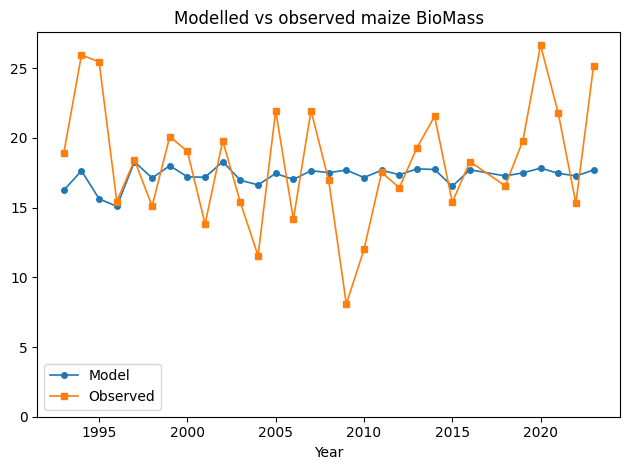

In [71]:
plot_yield_timeseries_comparison(seasonal_results, get_yield_for_comparison(LOCATION, "biomass", "A", "N3"), "BioMass")

=== Biomass ===
  RMSE:       4.3738
  R2:         -0.0147
  NSE:        -0.0147
  KGE:        -0.1681
  mKGE:       -0.1617
  KGE_r:      0.1912
  KGE_beta:   0.9467
  KGE_alpha:  0.1588
  mKGE_alpha: 0.1678


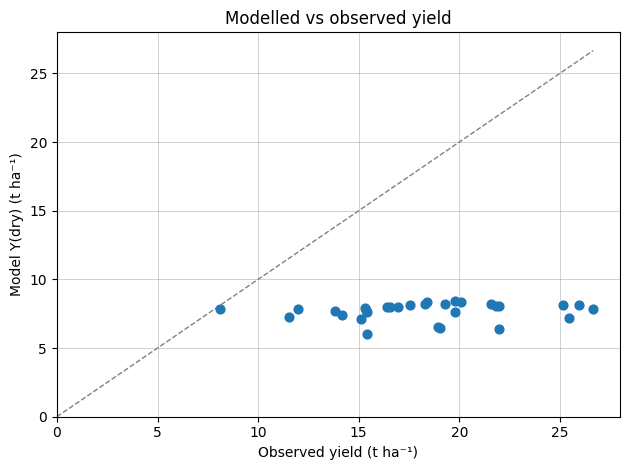

In [72]:
plot_yield_scatter(seasonal_results, get_yield(LOCATION, "biomass", "A", "N3"))
print_metrics(seasonal_results, get_yield_for_comparison(LOCATION, "biomass", "A", "N3"), "BioMass", "Biomass")

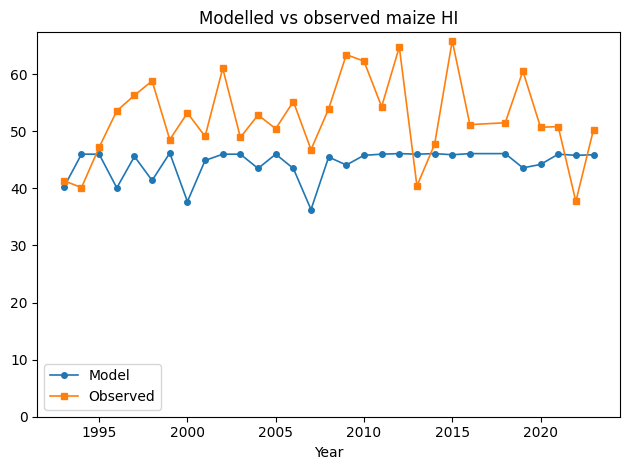

In [73]:
plot_yield_timeseries_comparison(seasonal_results, get_yield_for_comparison(LOCATION, "hi", "A", "N3"), "HI")

In [74]:
results["day"]

,Day,Month,Year,DAP,Stage,WC(2.30),Rain,Irri,Surf,Infilt,...,9_1,ECe10,ECe11,ECe12,Rain_1,ETo,Tmin,Tavg,Tmax,CO2
0,1,1,1993,-9,0,758.7,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
1,2,1,1993,-9,0,758.1,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
2,3,1,1993,-9,0,757.4,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
3,4,1,1993,-9,0,757.1,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
4,5,1,1993,-9,0,756.9,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,27,12,1993,-9,0,848.7,6.0,0.0,0.0,5.6,...,None,None,None,None,None,None,None,None,None,None
361,28,12,1993,-9,0,842.2,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
362,29,12,1993,-9,0,837.9,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
363,30,12,1993,-9,0,835.8,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None


<Axes: >

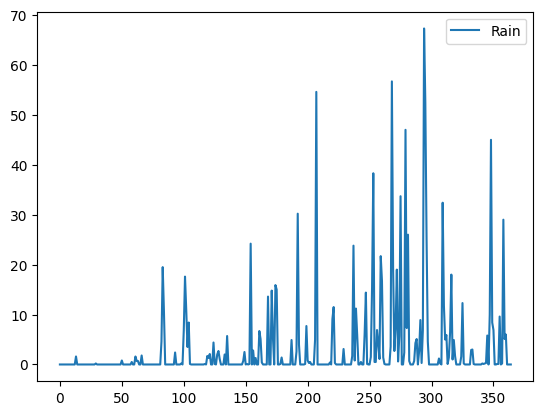

In [75]:
results["day"].plot(y="Rain")

<Axes: >

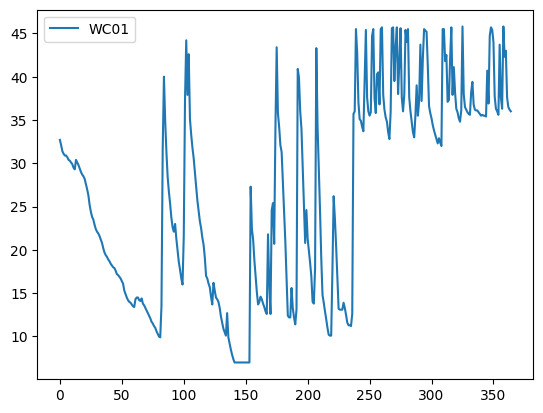

In [76]:
results["day"].plot(y="WC01")

<Axes: >

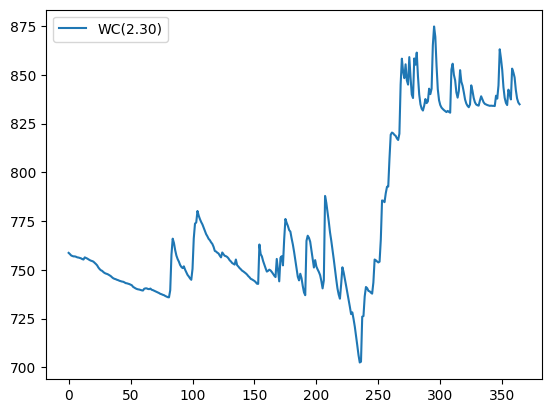

In [77]:
results["day"].plot(y="WC(2.30)")

<Axes: >

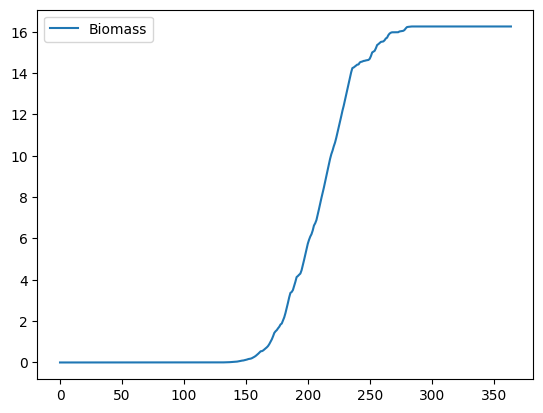

In [78]:
results["day"].plot(y="Biomass")

<Axes: >

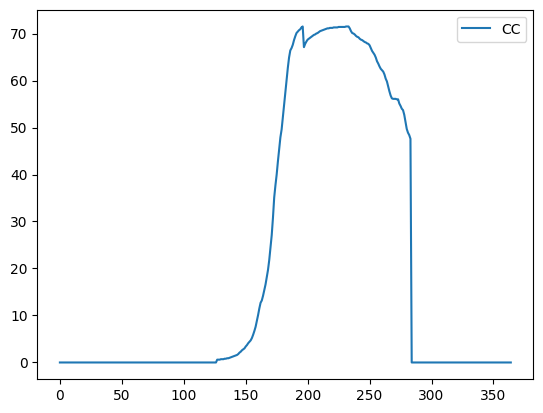

In [79]:
results["day"].plot(y="CC")

<Axes: >

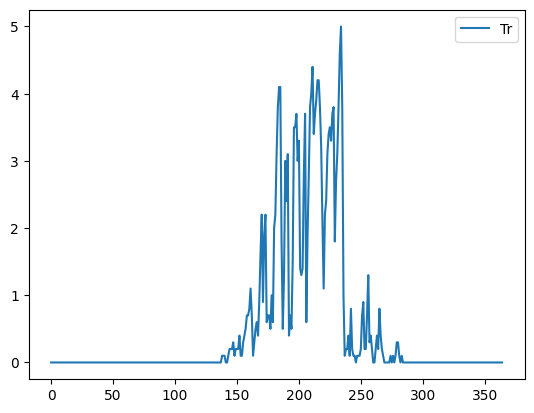

In [80]:
results["day"].plot(y="Tr")

<Axes: >

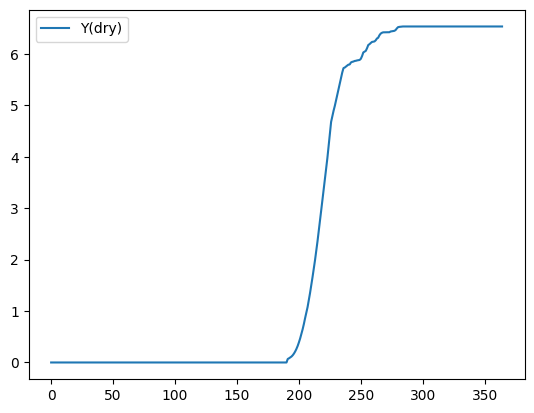

In [81]:
results["day"].plot(y="Y(dry)")